# Tamil Nadu 9BA hourly peak-week results analysis

This notebook analyzes the solved 168-hour nine-balancing-area peak week in \`9_BA/tamil_nadu_9ba_2025_26.nc\`.

It covers dispatch, unit commitment, storage, balancing-area supply and demand, inter-area transfers, corridor utilization, renewable generation, and hourly ramp adequacy. It contains no equipment-fault or forced-outage analysis.

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pypsa

ROOT = Path.cwd()
if not (ROOT / "9_BA").exists():
    ROOT = ROOT.parent

RESULT_FILE = ROOT / "9_BA" / "tamil_nadu_9ba_2025_26.nc"
n = pypsa.Network(RESULT_FILE)

assert len(n.snapshots) == 168
assert len(n.buses) == 9
assert len(n.links) == 22
assert (n.snapshots.to_series().diff().dropna() == pd.Timedelta(hours=1)).all()
assert (n.snapshot_weightings[["objective", "stores", "generators"]] == 1.0).all().all()

print(f"Loaded solved 9BA peak week from {RESULT_FILE}")
print(f"Period: {n.snapshots[0]} to {n.snapshots[-1]}")

INFO:pypsa.network.io:New version 1.3.0 available! (Current: 1.2.4)


INFO:pypsa.network.io:Imported network 'Tamil Nadu FY 2025-26 nine-balancing-area hourly UC inputs with July 2026 capacity overlay' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks


Loaded solved 9BA peak week from C:\Users\b076218\Documents\Filkassen\DEA_GE_github\PyPSA-TamilNadu\9_BA\tamil_nadu_9ba_2025_26.nc
Period: 2025-07-07 00:00:00 to 2025-07-13 23:00:00


In [2]:
n

PyPSA Network 'Tamil Nadu FY 2025-26 nine-balancing-area hourly UC inputs with July 2026 capacity overlay'
----------------------------------------------------------------------------------------------------------
Components:
 - Bus: 9
 - Carrier: 13
 - Generator: 407
 - GlobalConstraint: 1
 - Link: 22
 - Load: 9
 - StorageUnit: 4
 - SubNetwork: 9
Snapshots: 168

## System dispatch, storage, and coal commitment

The first figure reproduces the statewide view of the hourly model. It aggregates all nine balancing areas while retaining the spatial transmission constraints used in the optimization.

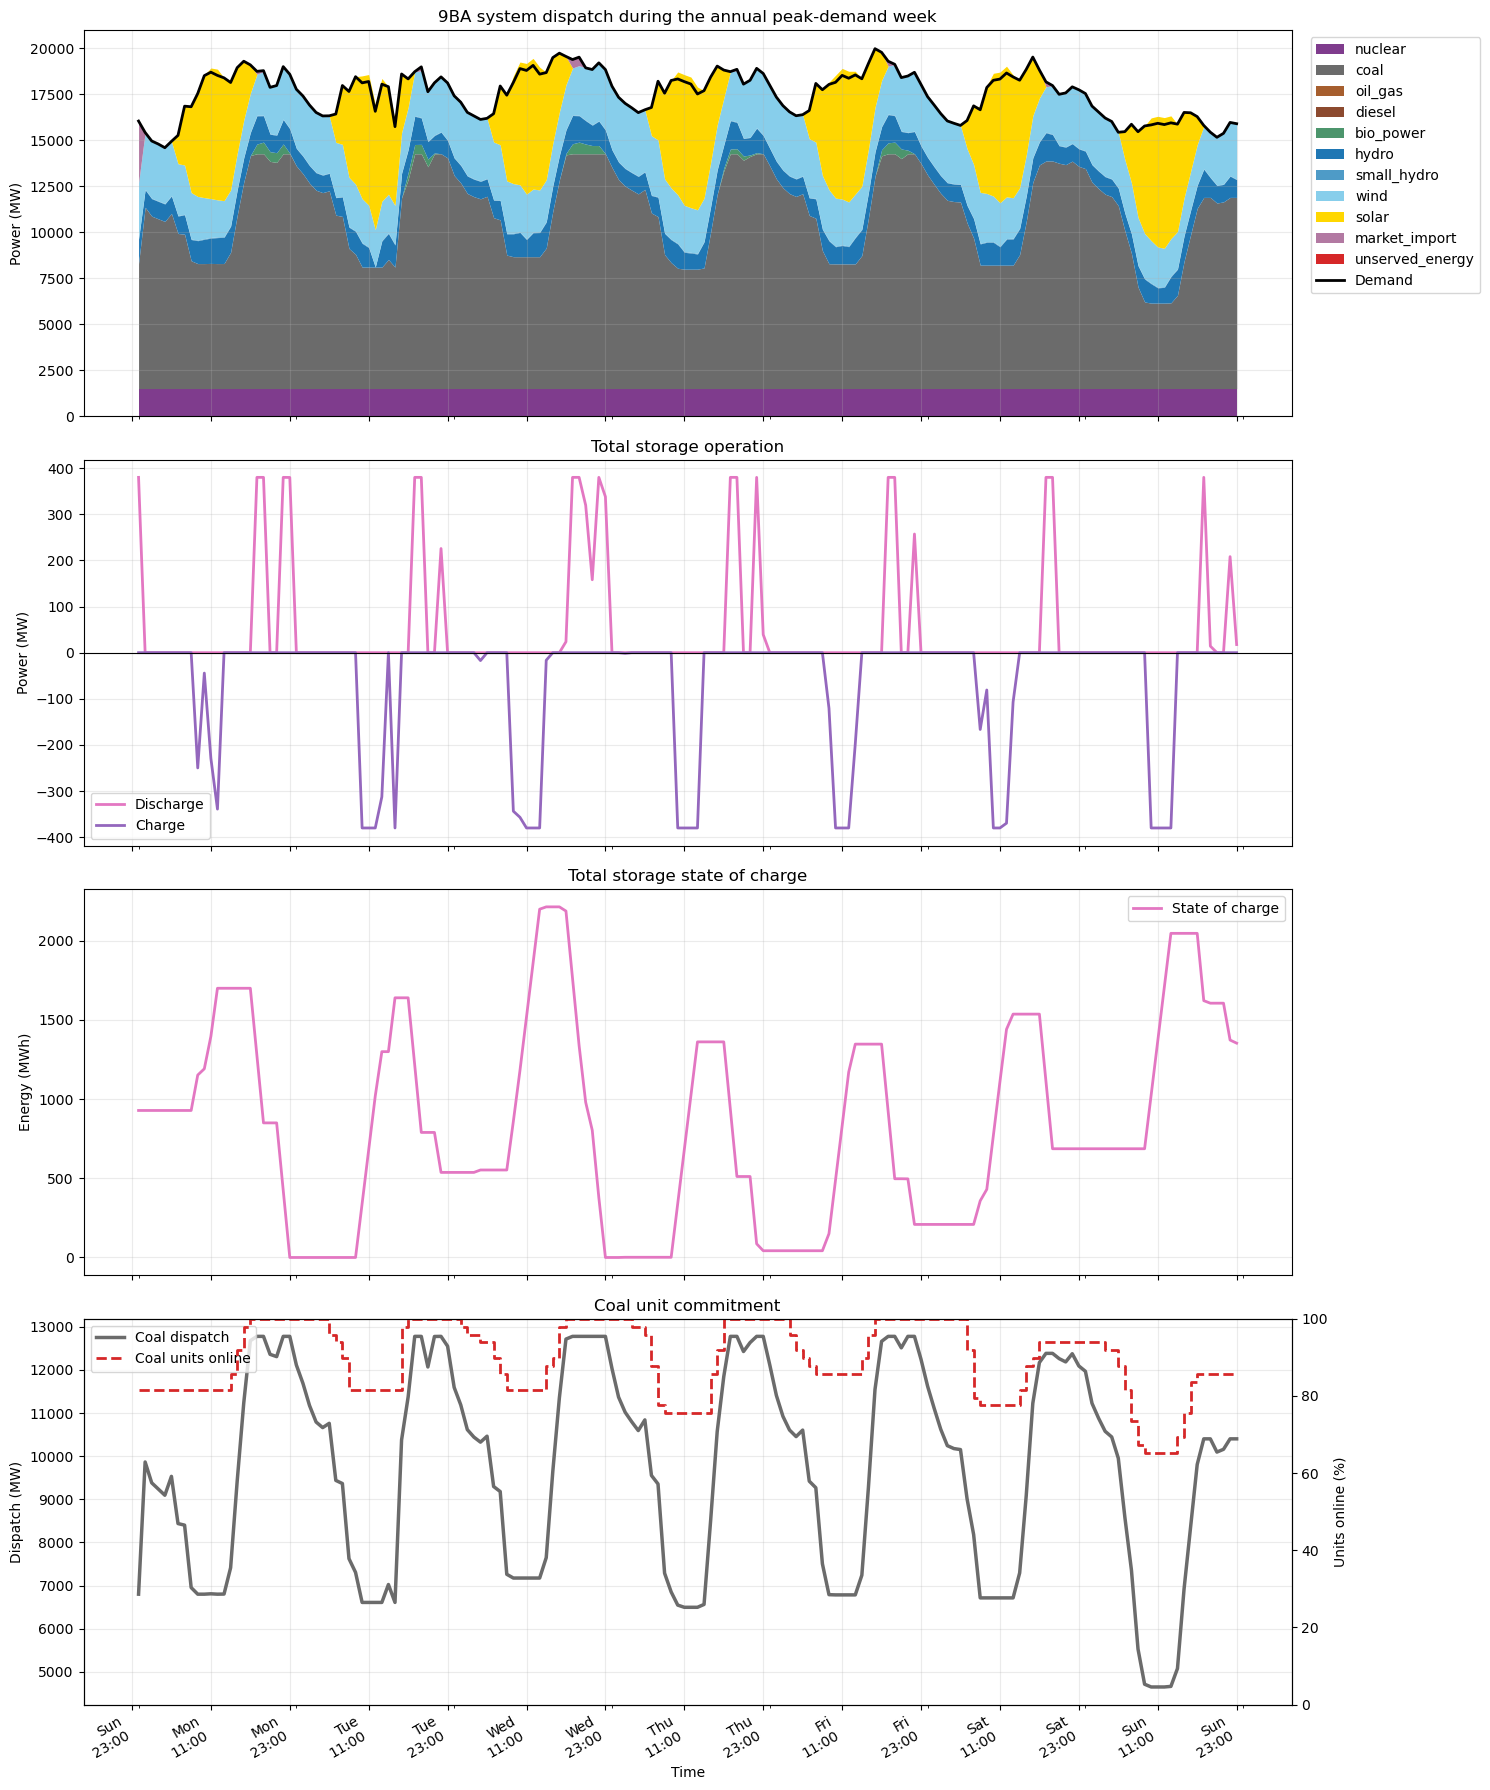

In [3]:
carrier_colors = {
    "nuclear": "#7F3C8D",
    "coal": "#6B6B6B",
    "oil_gas": "#A65E2E",
    "diesel": "#8C4A2F",
    "bio_power": "#4C956C",
    "hydro": "#1F77B4",
    "small_hydro": "#4E9BC7",
    "wind": "#87CEEB",
    "solar": "#FFD700",
    "market_import": "#B279A2",
    "unserved_energy": "#D62728",
}

generation = (
    n.generators_t.p.T.groupby(n.generators.carrier).sum().T.clip(lower=0)
)
storage_power = n.storage_units_t.p
storage_discharge = (
    storage_power.clip(lower=0)
    .T.groupby(n.storage_units.carrier).sum().T
)
supply = generation.add(storage_discharge, fill_value=0)
demand = n.loads_t.p_set.sum(axis=1)

carrier_order = [
    "nuclear", "coal", "oil_gas", "diesel", "bio_power", "hydro",
    "small_hydro", "wind", "solar", "market_import",
    "unserved_energy",
]
supply = supply[[carrier for carrier in carrier_order if carrier in supply.columns]]

fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

supply.plot.area(
    ax=axes[0], stacked=True, linewidth=0,
    color=[carrier_colors[c] for c in supply.columns], x_compat=True,
)
demand.plot(ax=axes[0], color="black", linewidth=2, label="Demand", x_compat=True)
axes[0].set_title("9BA system dispatch during the annual peak-demand week")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(loc="upper left", bbox_to_anchor=(1.01, 1))

storage_operation = pd.DataFrame({
    "Discharge": storage_power.clip(lower=0).sum(axis=1),
    "Charge": storage_power.clip(upper=0).sum(axis=1),
})
storage_operation.plot(
    ax=axes[1], linewidth=2, color=["#E377C2", "#9467BD"], x_compat=True
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Total storage operation")
axes[1].set_ylabel("Power (MW)")

n.storage_units_t.state_of_charge.sum(axis=1).plot(
    ax=axes[2], color="#E377C2", linewidth=2,
    label="State of charge", x_compat=True,
)
axes[2].set_title("Total storage state of charge")
axes[2].set_ylabel("Energy (MWh)")
axes[2].legend()

coal_units = n.generators.index[n.generators.carrier == "coal"]
coal_dispatch = n.generators_t.p[coal_units].sum(axis=1)
coal_online_pct = (
    100 * n.generators_t.status[coal_units].sum(axis=1) / len(coal_units)
)
coal_dispatch.plot(
    ax=axes[3], color=carrier_colors["coal"], linewidth=2.5,
    label="Coal dispatch", x_compat=True,
)
commitment_axis = axes[3].twinx()
coal_online_pct.plot(
    ax=commitment_axis, color="tab:red", linestyle="--",
    drawstyle="steps-post", linewidth=2, label="Coal units online",
    x_compat=True,
)
axes[3].set_title("Coal unit commitment")
axes[3].set_ylabel("Dispatch (MW)")
commitment_axis.set_ylabel("Units online (%)")
commitment_axis.set_ylim(0, 100)
lines1, labels1 = axes[3].get_legend_handles_labels()
lines2, labels2 = commitment_axis.get_legend_handles_labels()
axes[3].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

for axis in axes:
    axis.grid(alpha=0.25)
axes[3].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[3].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Balancing-area supply, demand, and transfers

Local generation and storage do not have to match local demand because the 22 corridors exchange power among areas. The peak-hour table reconciles demand with local supply, net imports, and unserved energy. Positive net imports mean that an area receives power from the grid.

Maximum reconstructed area-balance residual: 8.711e-10 MW
Balancing-area conditions at the statewide peak (2025-07-11 16:00:00):


,demand_MW,local_generation_MW,storage_MW,net_import_MW,unserved_MW,reconstructed_supply_MW
name,,,,,,
Chennai North,1695.99,4054.84,0.0,-2358.85,0.0,1695.99
Chennai South,2100.18,321.08,0.0,1779.10,0.0,2100.18
Coimbatore,3090.82,1647.57,0.0,1443.25,0.0,3090.82
Erode,2571.72,1435.25,0.0,1136.48,0.0,2571.72
Madurai,1969.41,1301.86,0.0,667.55,0.0,1969.41
Tirunelveli,1668.25,7371.40,0.0,-5703.15,0.0,1668.25
Trichy,2405.30,461.41,0.0,1943.89,0.0,2405.30
Vellore,2413.22,76.16,0.0,2337.06,0.0,2413.22
Villupuram,2072.44,3317.76,0.0,-1245.32,0.0,2072.44


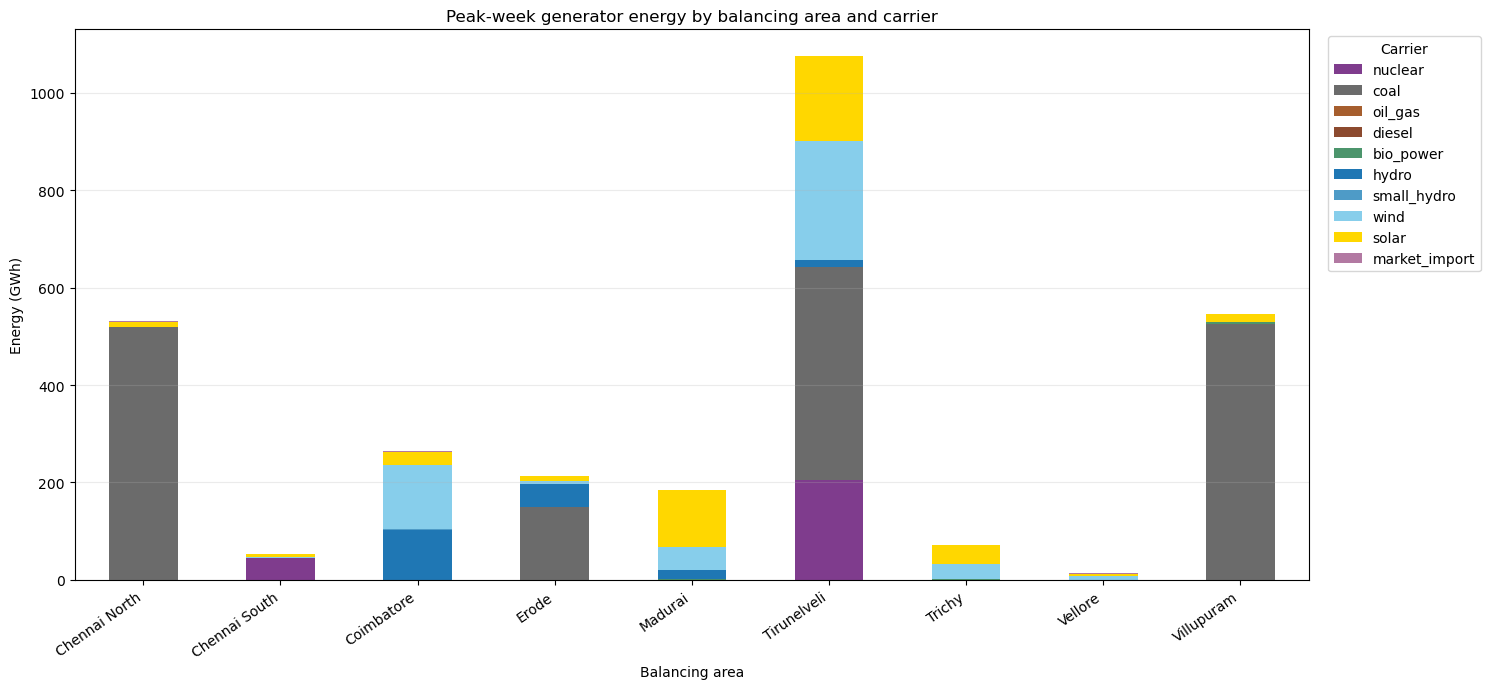

In [4]:
areas = n.buses.index
area_demand = n.loads_t.p_set.T.groupby(n.loads.bus).sum().T.reindex(columns=areas, fill_value=0)
area_generation = n.generators_t.p.T.groupby(n.generators.bus).sum().T.reindex(columns=areas, fill_value=0)
area_storage = n.storage_units_t.p.T.groupby(n.storage_units.bus).sum().T.reindex(columns=areas, fill_value=0)

net_imports = pd.DataFrame(0.0, index=n.snapshots, columns=areas)
for link in n.links.index:
    bus0 = n.links.at[link, "bus0"]
    bus1 = n.links.at[link, "bus1"]
    flow = n.links_t.p0[link]
    net_imports[bus0] -= flow
    net_imports[bus1] += flow * n.links.at[link, "efficiency"]

unserved_by_area = (
    n.generators_t.p[n.generators.index[n.generators.carrier == "unserved_energy"]]
    .T.groupby(n.generators.loc[n.generators.carrier == "unserved_energy", "bus"])
    .sum().T.reindex(columns=areas, fill_value=0)
)

area_residual = (
    area_generation + area_storage + net_imports - area_demand
).abs().max().max()
print(f"Maximum reconstructed area-balance residual: {area_residual:.3e} MW")

peak_time = demand.idxmax()
peak_area_summary = pd.DataFrame({
    "demand_MW": area_demand.loc[peak_time],
    "local_generation_MW": area_generation.loc[peak_time],
    "storage_MW": area_storage.loc[peak_time],
    "net_import_MW": net_imports.loc[peak_time],
    "unserved_MW": unserved_by_area.loc[peak_time],
})
peak_area_summary["reconstructed_supply_MW"] = (
    peak_area_summary.local_generation_MW
    + peak_area_summary.storage_MW
    + peak_area_summary.net_import_MW
)
print(f"Balancing-area conditions at the statewide peak ({peak_time}):")
display(peak_area_summary.round(2))

weights = n.snapshot_weightings.generators
generator_energy = n.generators_t.p.mul(weights, axis=0).sum()
energy_records = pd.DataFrame({
    "bus": generator_energy.index.map(n.generators.bus),
    "carrier": generator_energy.index.map(n.generators.carrier),
    "energy_GWh": generator_energy.to_numpy() / 1_000,
})
area_carrier_energy = energy_records.pivot_table(
    index="bus", columns="carrier", values="energy_GWh",
    aggfunc="sum", fill_value=0,
)
plot_carriers = [
    c for c in carrier_order
    if c in area_carrier_energy.columns and c != "unserved_energy"
]
area_carrier_energy[plot_carriers].plot.bar(
    stacked=True, figsize=(15, 7),
    color=[carrier_colors[c] for c in plot_carriers],
)
plt.title("Peak-week generator energy by balancing area and carrier")
plt.ylabel("Energy (GWh)")
plt.xlabel("Balancing area")
plt.xticks(rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend(title="Carrier", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Installed capacity by district

The left panel shows absolute operational nameplate capacity in MW, stacked by technology. The right panel shows each district's share of total statewide installed plant capacity. All 38 districts in the balancing-area mapping are retained, including districts with zero capacity in the source workbook.

The graph reads the workbook allocation and July-2026 overlay exported as `model/district_capacity_allocation.csv`. All modeled source rows reconcile exactly and every modeled allocation has a district. Allocation methods and confidence remain traceable; in particular, low-confidence proportional proxy allocations should not be interpreted as verified plant locations. The excluded 49.31 MW reporting difference, market-import, and unserved-energy mechanisms are not installed district plant.

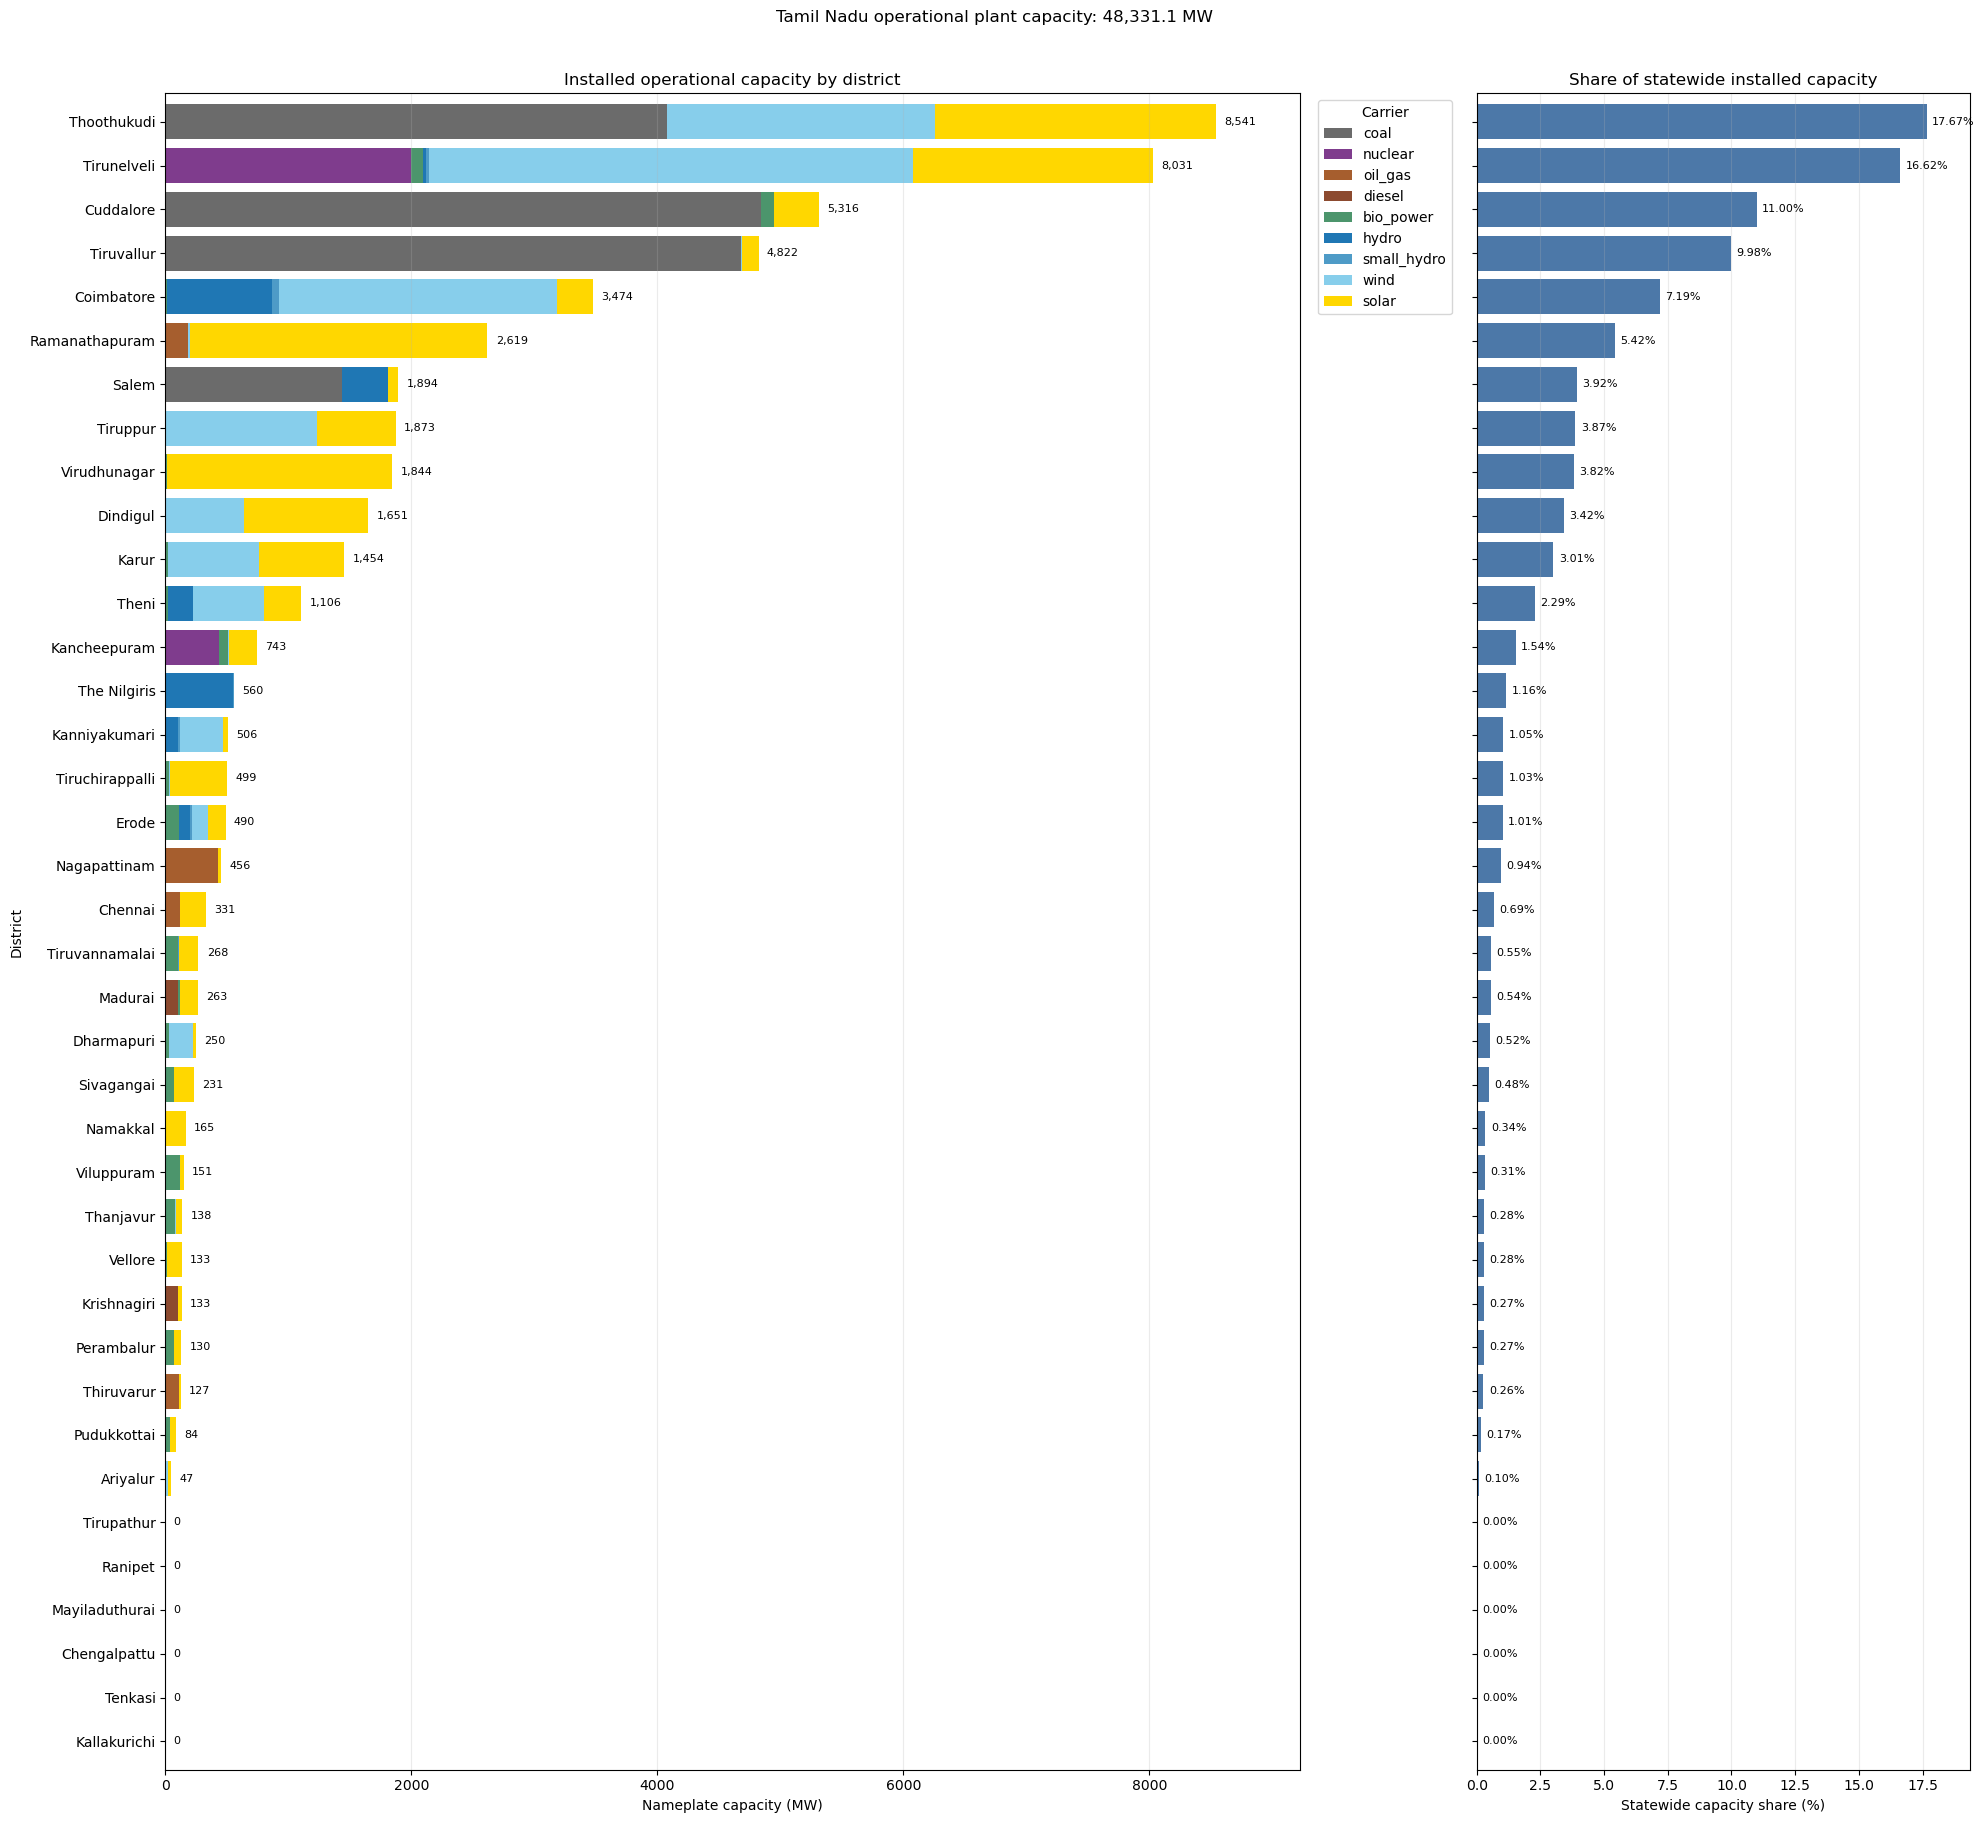

,installed_capacity_MW,statewide_capacity_share_pct
district,,
Thoothukudi,8540.594,17.671
Tirunelveli,8031.420,16.617
Cuddalore,5315.608,10.998
Tiruvallur,4822.475,9.978
Coimbatore,3474.002,7.188
Ramanathapuram,2618.740,5.418
Salem,1894.124,3.919
Tiruppur,1872.549,3.874
Virudhunagar,1844.049,3.815


In [5]:
DISTRICT_MAP_FILE = ROOT / "9_BA" / "Balancing_areas.txt"
PLANT_METADATA_FILE = (
    ROOT / "inputs" / "tamil_nadu_ra_2025_26" / "component_metadata.csv"
)

mapped_districts = []
for line in DISTRICT_MAP_FILE.read_text(encoding="utf-8").splitlines():
    if line.startswith("|") and "---" not in line and "District" not in line:
        mapped_districts.append(line.strip("|").split("|")[0].strip())
assert len(mapped_districts) == 38
assert len(set(mapped_districts)) == 38

plant_metadata = pd.read_csv(PLANT_METADATA_FILE)
source_to_carrier = {
    "Bio Power": "bio_power",
    "Coal": "coal",
    "Hydro": "hydro",
    "Nuclear": "nuclear",
    "Oil & Gas": "oil_gas",
    "Diesel": "diesel",
    "Small-Hydro": "small_hydro",
    "Solar": "solar",
    "Wind": "wind",
}
district_aliases = {
    "Thiruvallur": "Tiruvallur",
    "Nilgiris": "The Nilgiris",
    "Kanyakumari": "Kanniyakumari",
    "Kanchipuram": "Kancheepuram",
    "Sivaganga": "Sivagangai",
    "Thoothukkudi": "Thoothukudi",
    "Tuticorin": "Thoothukudi",
}
combined_districts = {
    "Tirunelveli, Tuticorin, Virudhunagar and Ramanathapuram": [
        "Tirunelveli", "Thoothukudi", "Virudhunagar", "Ramanathapuram"
    ],
    "Tiruppur & Karur": ["Tiruppur", "Karur"],
}
unlocated_districts = {"N.A.", "Location TBC"}

plant_metadata["reported_district"] = (
    plant_metadata.district.astype(str).str.strip()
)
plant_metadata["normalized_district"] = (
    plant_metadata.reported_district.replace(district_aliases)
)
direct_mask = ~plant_metadata.reported_district.isin(
    unlocated_districts | set(combined_districts)
)
direct_records = plant_metadata.loc[
    direct_mask, ["source", "normalized_district", "capacity_mw"]
].rename(columns={"normalized_district": "district"})

known_capacity = direct_records.groupby(["source", "district"]).capacity_mw.sum()
allocation_records = direct_records.to_dict("records")

for reported_name, candidates in combined_districts.items():
    combined_rows = plant_metadata.loc[
        plant_metadata.reported_district == reported_name
    ]
    for _, component in combined_rows.iterrows():
        source = component.source
        weights = pd.Series(
            {
                district: known_capacity.get((source, district), 0.0)
                for district in candidates
            },
            dtype=float,
        )
        if weights.sum() <= 0:
            weights[:] = 1.0
        weights /= weights.sum()
        for district, share in weights.items():
            allocation_records.append({
                "source": source,
                "district": district,
                "capacity_mw": component.capacity_mw * share,
            })

for _, component in plant_metadata.loc[
    plant_metadata.reported_district.isin(unlocated_districts)
].iterrows():
    allocation_records.append({
        "source": component.source,
        "district": "Unspecified",
        "capacity_mw": component.capacity_mw,
    })

district_capacity_records = pd.DataFrame(allocation_records)
district_capacity_records["carrier"] = district_capacity_records.source.map(
    source_to_carrier
)
assert district_capacity_records.carrier.notna().all()
assert np.isclose(
    district_capacity_records.capacity_mw.sum(),
    plant_metadata.capacity_mw.sum(),
)

capacity_by_district = district_capacity_records.pivot_table(
    index="district",
    columns="carrier",
    values="capacity_mw",
    aggfunc="sum",
    fill_value=0.0,
).reindex([*mapped_districts, "Unspecified"], fill_value=0.0)

capacity_allocation = pd.read_csv(
    ROOT / "9_BA" / "model" / "district_capacity_allocation.csv"
)
capacity_allocation["district"] = (
    capacity_allocation.allocated_district.replace(district_aliases)
)
capacity_allocation["carrier"] = capacity_allocation.source.map(
    source_to_carrier
)
assert capacity_allocation.carrier.notna().all()
assert set(capacity_allocation.district) <= set(mapped_districts)
capacity_by_district = capacity_allocation.pivot_table(
    index="district",
    columns="carrier",
    values="allocated_capacity_mw",
    aggfunc="sum",
    fill_value=0.0,
).reindex(mapped_districts, fill_value=0.0)
assert np.isclose(
    capacity_by_district.to_numpy().sum(),
    capacity_allocation.allocated_capacity_mw.sum(),
)

capacity_carrier_order = [
    carrier for carrier in [
        "coal", "nuclear", "oil_gas", "diesel", "bio_power", "hydro",
        "small_hydro", "wind", "solar",
    ]
    if carrier in capacity_by_district.columns
]
capacity_by_district = capacity_by_district[capacity_carrier_order]
district_totals = capacity_by_district.sum(axis=1)
statewide_capacity_mw = district_totals.sum()
district_shares_pct = 100 * district_totals / statewide_capacity_mw

plot_order = district_totals.sort_values().index
capacity_plot = capacity_by_district.loc[plot_order]
share_plot = district_shares_pct.loc[plot_order]

fig, axes = plt.subplots(
    1, 2, figsize=(20, 18),
    gridspec_kw={"width_ratios": [2.3, 1]},
    sharey=True,
)
capacity_plot.plot.barh(
    stacked=True,
    ax=axes[0],
    color=[carrier_colors[c] for c in capacity_carrier_order],
    width=0.8,
)
axes[0].set_title("Installed operational capacity by district")
axes[0].set_xlabel("Nameplate capacity (MW)")
axes[0].set_ylabel("District")
axes[0].grid(axis="x", alpha=0.25)
axes[0].legend(
    title="Carrier", bbox_to_anchor=(1.01, 1), loc="upper left"
)
absolute_offset = max(district_totals.max() * 0.008, 10)
for y_position, district in enumerate(plot_order):
    value = district_totals.at[district]
    axes[0].text(
        value + absolute_offset, y_position, f"{value:,.0f}",
        va="center", fontsize=8,
    )
axes[0].set_xlim(
    0, district_totals.max() + 10 * absolute_offset
)

share_plot.plot.barh(
    ax=axes[1], color="#4C78A8", width=0.8, legend=False
)
axes[1].set_title("Share of statewide installed capacity")
axes[1].set_xlabel("Statewide capacity share (%)")
axes[1].grid(axis="x", alpha=0.25)
share_offset = max(district_shares_pct.max() * 0.012, 0.05)
for y_position, district in enumerate(plot_order):
    value = district_shares_pct.at[district]
    axes[1].text(
        value + share_offset, y_position, f"{value:.2f}%",
        va="center", fontsize=8,
    )
axes[1].set_xlim(
    0, district_shares_pct.max() + 8 * share_offset
)

plt.suptitle(
    f"Tamil Nadu operational plant capacity: "
    f"{statewide_capacity_mw:,.1f} MW",
    y=1.01,
)
plt.tight_layout()
plt.show()

district_capacity_summary = pd.DataFrame({
    "installed_capacity_MW": district_totals,
    "statewide_capacity_share_pct": district_shares_pct,
}).sort_values("installed_capacity_MW", ascending=False)
display(district_capacity_summary.round(3))

## Transmission flows and corridor utilization

Positive flow is from each corridor's \`bus0\` to \`bus1\`; negative flow is the reverse direction. Utilization uses the absolute flow divided by the corridor rating. A value near 100% indicates a binding or nearly binding transfer limit.

,bus0,bus1,capacity_MW,maximum_absolute_flow_MW,maximum_loading_pct,hours_at_or_above_99pct,mean_loading_pct
name,,,,,,,
villupuram__tirunelveli,Villupuram,Tirunelveli,1000.0,1000.00,100.00,118,84.24
villupuram__erode,Villupuram,Erode,1000.0,1000.00,100.00,168,100.00
coimbatore__tirunelveli,Coimbatore,Tirunelveli,1000.0,1000.00,100.00,36,42.00
erode__tirunelveli,Erode,Tirunelveli,1000.0,1000.00,100.00,90,76.32
erode__coimbatore,Erode,Coimbatore,5000.0,5000.00,100.00,168,100.00
trichy__madurai,Trichy,Madurai,7000.0,7000.00,100.00,165,99.65
villupuram__coimbatore,Villupuram,Coimbatore,1000.0,1000.00,100.00,167,99.96
chennai_north__vellore,Chennai North,Vellore,1000.0,1000.00,100.00,168,100.00
vellore__tirunelveli,Vellore,Tirunelveli,2500.0,2500.00,100.00,148,96.78


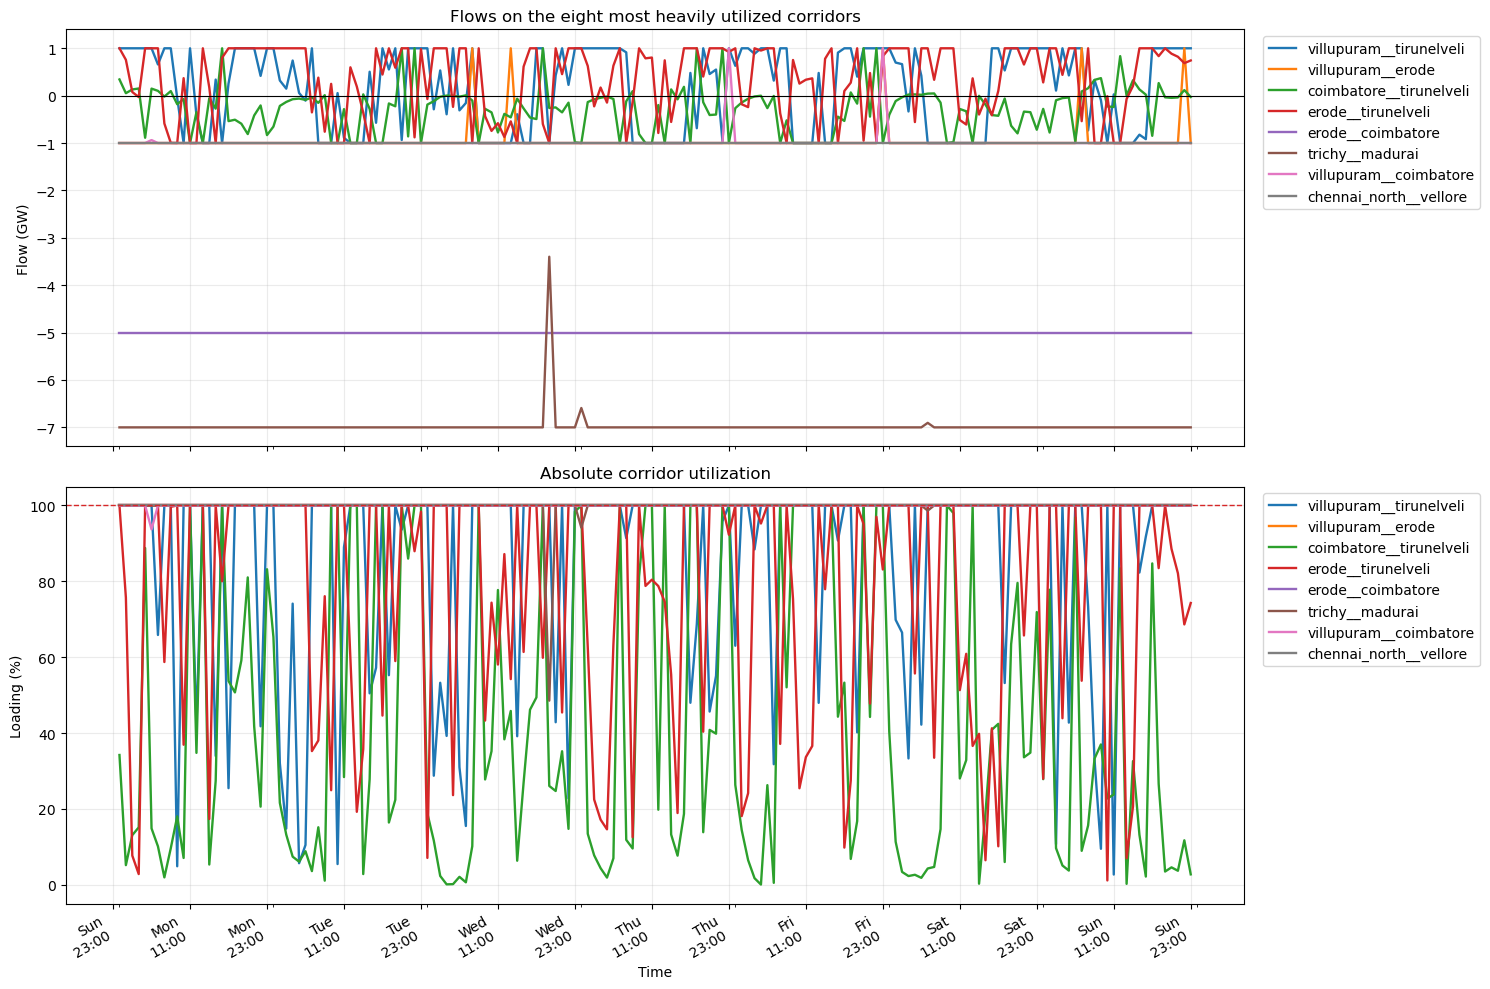

In [6]:
link_flows = n.links_t.p0
link_loading = link_flows.abs().div(n.links.p_nom, axis=1)
corridor_summary = pd.DataFrame({
    "bus0": n.links.bus0,
    "bus1": n.links.bus1,
    "capacity_MW": n.links.p_nom,
    "maximum_absolute_flow_MW": link_flows.abs().max(),
    "maximum_loading_pct": 100 * link_loading.max(),
    "hours_at_or_above_99pct": (link_loading >= 0.99).sum(),
    "mean_loading_pct": 100 * link_loading.mean(),
}).sort_values("maximum_loading_pct", ascending=False)

display(corridor_summary.round(2))

top_corridors = corridor_summary.head(8).index
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
(link_flows[top_corridors] / 1_000).plot(ax=axes[0], linewidth=1.7, x_compat=True)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Flows on the eight most heavily utilized corridors")
axes[0].set_ylabel("Flow (GW)")
axes[0].legend(bbox_to_anchor=(1.01, 1), loc="upper left")

(100 * link_loading[top_corridors]).plot(
    ax=axes[1], linewidth=1.7, x_compat=True
)
axes[1].axhline(100, color="tab:red", linestyle="--", linewidth=1)
axes[1].set_title("Absolute corridor utilization")
axes[1].set_ylabel("Loading (%)")
axes[1].set_xlabel("Time")
axes[1].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Solar and wind generation by balancing area

These are optimized outputs rather than raw availability, so they include any curtailment. The current model uses placeholder area profiles until spatially resolved hourly solar and wind data are supplied.

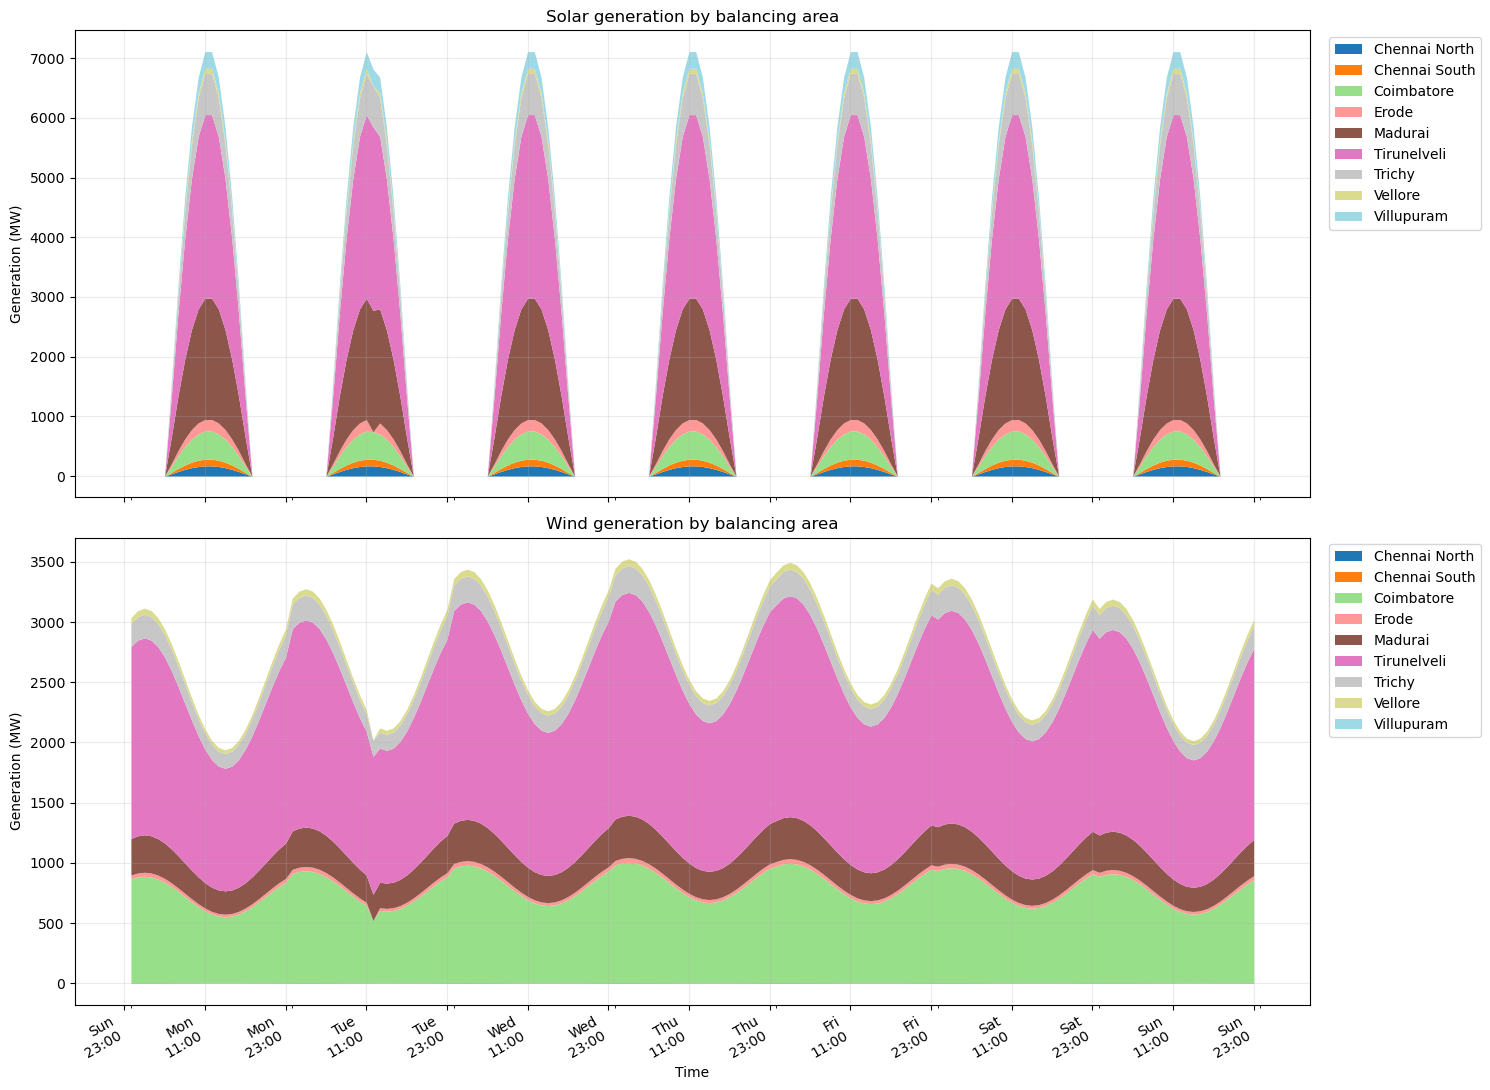

In [7]:
vre_by_area = {}
for carrier in ["solar", "wind"]:
    units = n.generators.index[n.generators.carrier == carrier]
    vre_by_area[carrier] = (
        n.generators_t.p[units].T.groupby(n.generators.loc[units, "bus"]).sum().T
        .reindex(columns=areas, fill_value=0)
    )

fig, axes = plt.subplots(2, 1, figsize=(15, 11), sharex=True)
for axis, carrier in zip(axes, ["solar", "wind"]):
    vre_by_area[carrier].plot.area(
        ax=axis, stacked=True, linewidth=0, colormap="tab20", x_compat=True
    )
    axis.set_title(f"{carrier.title()} generation by balancing area")
    axis.set_ylabel("Generation (MW)")
    axis.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    axis.grid(alpha=0.25)
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Hourly flexibility and ramp adequacy

System net load is demand minus solar and wind generation. The calculation reconstructs the applicable PyPSA upward-ramp allowance for committable generators. These are changes between hourly averages and do not represent equipment faults or intra-hour behavior.

Largest evening net-load increase: 4,273.5 MW/h at 2025-07-08 16:00:00
Dispatchable plus storage response: 4,273.5 MW
Committable generators starting: 14; at or above 95% of upward allowance: 14
Unserved energy: 0.000000 MWh


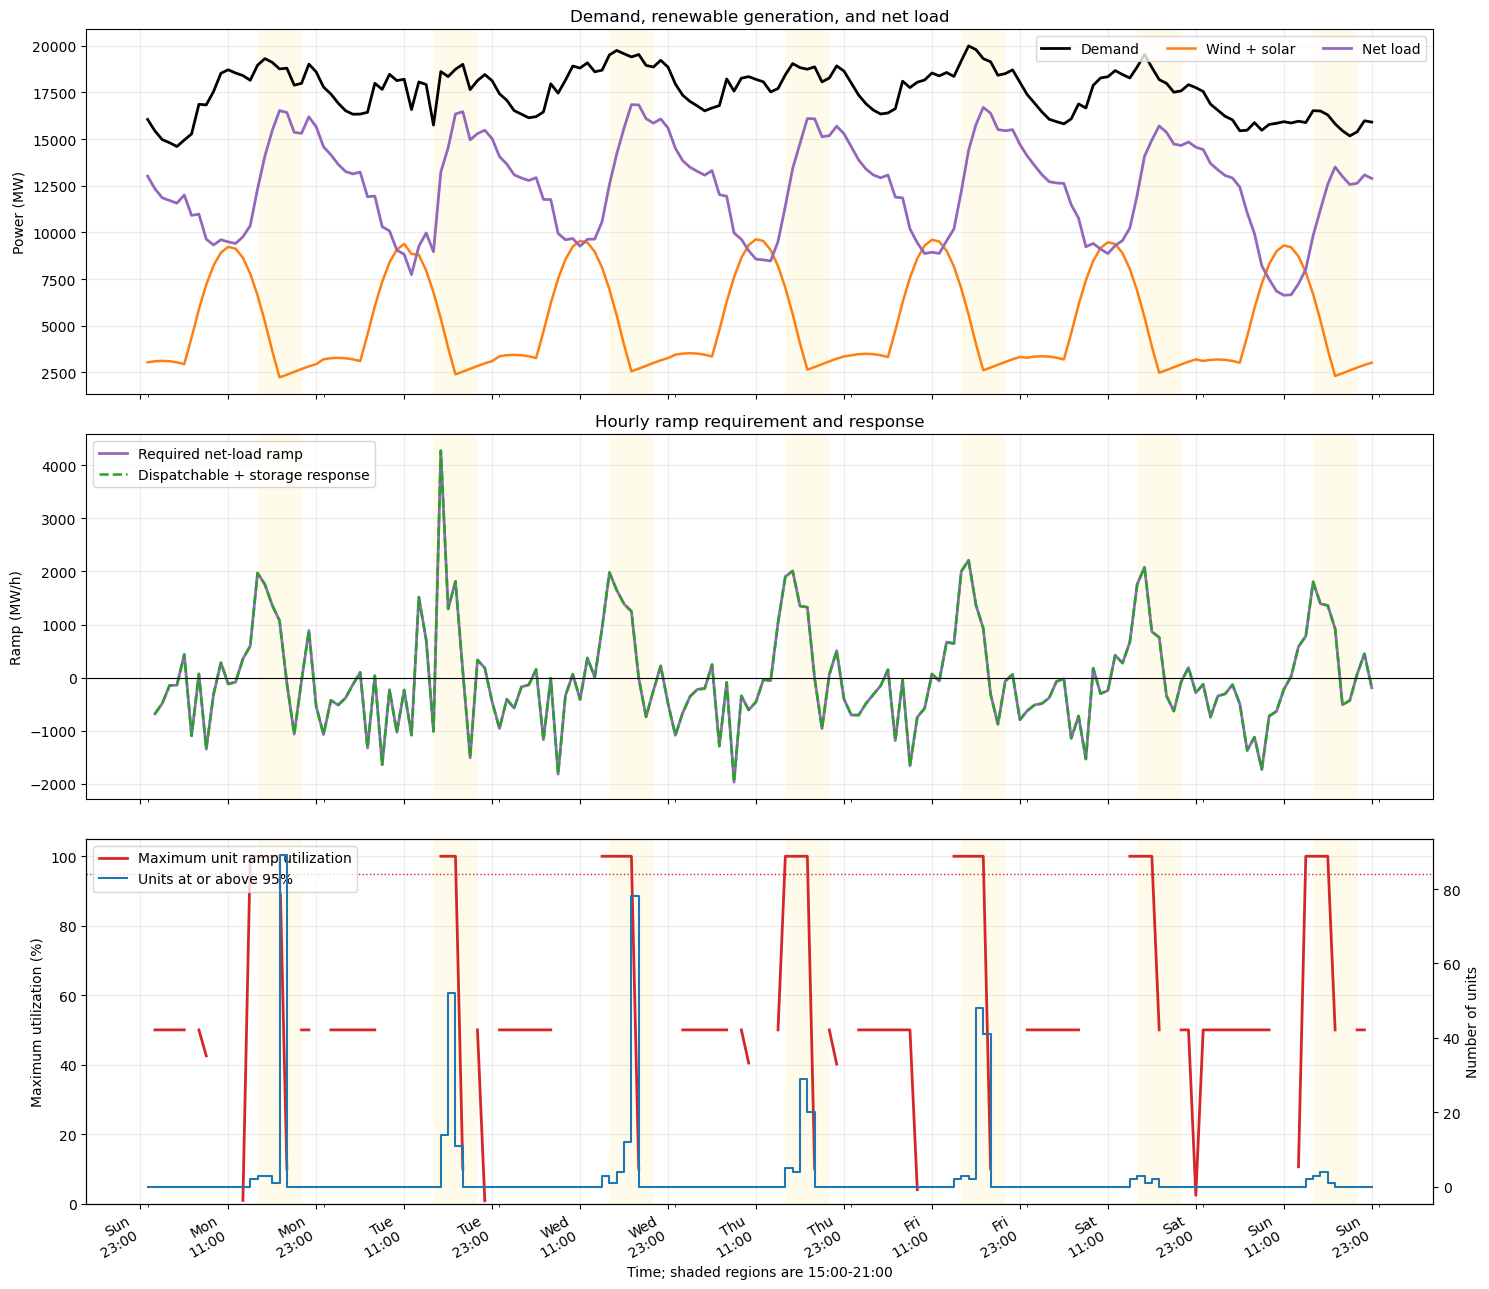

In [8]:
vre_generation = generation.reindex(
    columns=["solar", "wind"], fill_value=0
).sum(axis=1)
net_load = demand - vre_generation
net_load_ramp = net_load.diff()

dispatchable_carriers = [
    "coal", "oil_gas", "diesel", "bio_power", "hydro",
    "small_hydro", "market_import",
]
dispatchable_generation = generation.reindex(
    columns=dispatchable_carriers, fill_value=0
).sum(axis=1)
dispatchable_response = dispatchable_generation + storage_power.sum(axis=1)
dispatchable_response_ramp = dispatchable_response.diff()

ramp_units = n.generators.index[
    n.generators.committable & n.generators.ramp_limit_up.notna()
]
unit_dispatch = n.generators_t.p[ramp_units]
unit_status = n.generators_t.status[ramp_units].round()
previous_dispatch = unit_dispatch.shift(1)
previous_status = unit_status.shift(1)
unit_increase = unit_dispatch - previous_dispatch
status_change = unit_status - previous_status

p_nom = n.generators.loc[ramp_units, "p_nom"]
normal_up = n.generators.loc[ramp_units, "ramp_limit_up"]
start_up = n.generators.loc[ramp_units, "ramp_limit_start_up"]
allowed_up = (
    previous_status.mul(p_nom * normal_up, axis=1)
    + status_change.mul(p_nom * start_up, axis=1)
)
ramp_utilization = unit_increase.where(unit_increase > 1e-6).div(
    allowed_up.where(allowed_up > 0)
)
binding_units = ramp_utilization.ge(0.95).sum(axis=1)
starting_units = status_change.gt(0.5).sum(axis=1)
max_utilization = ramp_utilization.max(axis=1).clip(upper=1.0)

unserved = generation.get("unserved_energy", pd.Series(0.0, index=n.snapshots))
unserved_mwh = (unserved * weights).sum()
evening = net_load_ramp.index.hour.isin(range(15, 22))
peak_ramp_time = net_load_ramp.loc[evening].idxmax()

print(
    f"Largest evening net-load increase: "
    f"{net_load_ramp.at[peak_ramp_time]:,.1f} MW/h at {peak_ramp_time}"
)
print(
    f"Dispatchable plus storage response: "
    f"{dispatchable_response_ramp.at[peak_ramp_time]:,.1f} MW"
)
print(
    f"Committable generators starting: {starting_units.at[peak_ramp_time]:.0f}; "
    f"at or above 95% of upward allowance: "
    f"{binding_units.at[peak_ramp_time]:.0f}"
)
print(f"Unserved energy: {unserved_mwh:,.6f} MWh")

fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)
demand.plot(ax=axes[0], color="black", linewidth=2, label="Demand", x_compat=True)
vre_generation.plot(
    ax=axes[0], color="tab:orange", linewidth=1.8,
    label="Wind + solar", x_compat=True,
)
net_load.plot(
    ax=axes[0], color="tab:purple", linewidth=2,
    label="Net load", x_compat=True,
)
axes[0].set_title("Demand, renewable generation, and net load")
axes[0].set_ylabel("Power (MW)")
axes[0].legend(ncol=3)

net_load_ramp.plot(
    ax=axes[1], color="tab:purple", linewidth=2,
    label="Required net-load ramp", x_compat=True,
)
dispatchable_response_ramp.plot(
    ax=axes[1], color="tab:green", linestyle="--", linewidth=1.8,
    label="Dispatchable + storage response", x_compat=True,
)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Hourly ramp requirement and response")
axes[1].set_ylabel("Ramp (MW/h)")
axes[1].legend()

(100 * max_utilization).plot(
    ax=axes[2], color="tab:red", linewidth=2,
    label="Maximum unit ramp utilization", x_compat=True,
)
axes[2].axhline(95, color="tab:red", linestyle=":", linewidth=1)
axes[2].set_ylim(0, 105)
axes[2].set_ylabel("Maximum utilization (%)")
binding_axis = axes[2].twinx()
binding_units.plot(
    ax=binding_axis, color="tab:blue", drawstyle="steps-post",
    label="Units at or above 95%", x_compat=True,
)
binding_axis.set_ylabel("Number of units")
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = binding_axis.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

for day in pd.DatetimeIndex(n.snapshots.normalize().unique()):
    for axis in axes:
        axis.axvspan(
            day + pd.Timedelta(hours=15),
            day + pd.Timedelta(hours=21),
            color="gold", alpha=0.08, linewidth=0,
        )
for axis in axes:
    axis.grid(alpha=0.25)
axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=12))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%a\n%H:%M"))
axes[2].set_xlabel("Time; shaded regions are 15:00-21:00")
plt.tight_layout()
plt.show()

In [9]:
carrier_ramps = generation.reindex(
    columns=dispatchable_carriers, fill_value=0
).diff()
interval_summary = pd.DataFrame({
    "net_load_ramp_MW_per_h": net_load_ramp,
    "dispatchable_response_MW": dispatchable_response_ramp,
    "coal_response_MW": carrier_ramps["coal"],
    "oil_gas_response_MW": carrier_ramps["oil_gas"],
    "diesel_response_MW": carrier_ramps["diesel"],
    "bio_power_response_MW": carrier_ramps["bio_power"],
    "hydro_response_MW": carrier_ramps["hydro"],
    "storage_response_MW": storage_power.sum(axis=1).diff(),
    "committable_startups": starting_units,
    "units_at_or_above_95pct_ramp": binding_units,
    "maximum_corridor_loading_pct": 100 * link_loading.max(axis=1),
    "unserved_energy_MW": unserved,
})

print("Largest late-afternoon and evening system ramps:")
display(
    interval_summary.loc[evening]
    .nlargest(10, "net_load_ramp_MW_per_h")
    .round(2)
)

print("Balancing-area weekly demand and net imports:")
area_week_summary = pd.DataFrame({
    "demand_GWh": area_demand.mul(weights, axis=0).sum() / 1_000,
    "net_import_GWh": net_imports.mul(weights, axis=0).sum() / 1_000,
    "peak_demand_MW": area_demand.max(),
    "peak_net_import_MW": net_imports.max(),
    "minimum_net_import_MW": net_imports.min(),
})
display(area_week_summary.round(2))

Largest late-afternoon and evening system ramps:


,net_load_ramp_MW_per_h,dispatchable_response_MW,coal_response_MW,oil_gas_response_MW,diesel_response_MW,bio_power_response_MW,hydro_response_MW,storage_response_MW,committable_startups,units_at_or_above_95pct_ramp,maximum_corridor_loading_pct,unserved_energy_MW
snapshot,,,,,,,,,,,,
2025-07-08 16:00:00,4273.45,4273.45,3766.14,0.0,0.0,7.22,121.55,380.00,14,14,100.0,0.0
2025-07-11 16:00:00,2211.46,2211.46,2269.53,0.0,0.0,0.00,-56.62,0.00,2,2,100.0,0.0
2025-07-12 16:00:00,2081.00,2081.00,2139.08,0.0,0.0,0.00,-56.62,0.00,1,1,100.0,0.0
2025-07-10 16:00:00,2008.19,2008.19,2065.88,0.0,0.0,0.39,-56.62,0.00,4,4,100.0,0.0
2025-07-11 15:00:00,2000.46,2000.46,2036.52,0.0,0.0,0.00,-35.15,0.00,3,3,100.0,0.0
2025-07-09 15:00:00,1981.22,1981.22,2000.89,0.0,0.0,0.00,-35.15,16.39,1,1,100.0,0.0
2025-07-07 15:00:00,1971.74,1971.74,2007.80,0.0,0.0,0.00,-35.15,0.00,3,3,100.0,0.0
2025-07-10 15:00:00,1903.22,1903.22,1939.28,0.0,0.0,0.00,-35.15,-0.00,5,5,100.0,0.0
2025-07-08 18:00:00,1813.55,1813.55,1403.03,0.0,0.0,122.09,-90.11,380.00,11,11,100.0,0.0


Balancing-area weekly demand and net imports:


,demand_GWh,net_import_GWh,peak_demand_MW,peak_net_import_MW,minimum_net_import_MW
name,,,,,
Chennai North,0.0,0.0,1695.99,-235.62,-2639.63
Chennai South,0.0,0.0,2100.18,1779.10,1278.75
Coimbatore,0.0,0.0,3090.82,1952.74,-349.12
Erode,0.0,0.0,2571.72,1655.25,456.76
Madurai,0.0,0.0,1969.41,1469.79,-735.41
Tirunelveli,0.0,0.0,1668.25,-3322.24,-6277.06
Trichy,0.0,0.0,2405.30,2064.58,933.67
Vellore,0.0,0.0,2413.22,2337.06,1079.06
Villupuram,0.0,0.0,2072.44,159.87,-2498.72
